# CSP-7 : Contraintes Souples - Soft CSP

**Navigation** : [<< CSP-6-Hybridization](CSP-6-Hybridization.ipynb) | [Index](../README.md) | [CSP-8-Temporal >>](CSP-8-Temporal.ipynb)

## Problemes de Satisfaction de Contraintes Souples

Ce notebook explore les extensions du formalisme CSP classique pour gerer les **preferences** et les **contraintes violables**. Contrairement au CSP classique (binaire : satisfait/non satisfait), les **Soft CSP** attribuent des degres de satisfaction.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** les limitations du CSP classique binaire (Bloom : comprendre)
2. **Decouvrir** le framework semiring-based CSP unifie (Bloom : comprendre)
3. **Implementer** des Fuzzy CSP avec degres d'appartenance (Bloom : appliquer)
4. **Resoudre** des Weighted CSP avec couts de violation (Bloom : appliquer)
5. **Appliquer** les contraintes souples aux problemes de preferences (Bloom : analyser)

### Prerequis
- CSP-1 : formalisme CSP classique
- CSP-2 : propagation de contraintes
- Bases d'algebre (semirings)

### Duree estimee : 60 minutes

---

## 1. Introduction : Pourquoi les contraintes souples ? (~10 min)

Dans le CSP classique, une contrainte est soit **satisfaite** soit **violee**. Cette vision binaire est limitee dans de nombreuses situations reelles :

### Exemples de problemes

1. **Planning de vacances** : "Je prefererais partir en juillet, mais aout est acceptable"
2. **Recommandation** : "L'utilisateur prefere les films d'action, mais peut regarder autre chose"
3. **Allocation de ressources** : "Le budget ideal est 1000 EUR, mais 1200 EUR est tolerable"

### Taxonomie des Soft CSP

| Type | Valeurs | Combinaison | Application |
|------|---------|-------------|-------------|
| **Fuzzy CSP** | [0, 1] | min/max | Preferences floues |
| **Weighted CSP** | Reels positifs | somme | Couts de violation |
| **Probabilistic CSP** | [0, 1] | produit | Incertitude |
| **Valued CSP** | Semi-anneau | operateur * | General |

### Approche unifiee : Semiring-based CSP

Tous ces types peuvent etre unifies avec la notion de **semi-anneau** $(S, +, \times)$ :
- $S$ : ensemble des valeurs de preference
- $+$ : operateur de combinaison (agrege les contraintes)
- $\times$ : operateur de projection (propagation)

In [1]:
# Installation des dependances
import subprocess
import sys
from itertools import product

def install_if_missing(package):
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing('ortools')
install_if_missing('matplotlib')
install_if_missing('numpy')

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Optional, Any
from dataclasses import dataclass
from abc import ABC, abstractmethod

print("Dependances pretes.")

Dependances pretes.


---

## 2. Semiring-based CSP : Framework Algebrique (~15 min)

### Definition formelle

Un **semi-anneau** (semiring) est une structure algebrique $(S, +, \times)$ avec :
- $S$ : ensemble non vide
- $+$ : operateur commutatif, associatif, element neutre $\bot$
- $\times$ : operateur associatif, element neutre $\top$
- Distributivite de $\times$ sur $+$

### Exemples de semi-anneaux pour CSP

| Semi-anneau | S | + (combinaison) | x (projection) | Application |
|-------------|---|-----------------|----------------|-------------|
| **Booleen** | {True, False} | or | and | CSP classique |
| **Fuzzy** | [0, 1] | max | min | Preferences |
| **Weighted** | R+ U {+inf} | min | + | Couts |
| **Probabilistic** | [0, 1] | max | x | Incertitude |

### Proprietes cles

- **$ot$** : pire valeur (False, 0, +inf, 0)
- **$	op$** : meilleure valeur (True, 1, 0, 1)
- L'ordre est defini par : $a \leq_S b$ ssi $a + b = b$

In [2]:
from abc import ABC, abstractmethod

class Semiring(ABC):
    """Base class for semirings used in Soft CSP."""
    
    @property
    @abstractmethod
    def bottom(self):
        """Element neutre de + (pire valeur)."""
        pass
    
    @property
    @abstractmethod
    def top(self):
        """Element neutre de x (meilleure valeur)."""
        pass
    
    @abstractmethod
    def combine(self, a, b):
        """Operateur + (combinaison/agregation)."""
        pass
    
    @abstractmethod
    def project(self, a, b):
        """Operateur x (projection/propagation)."""
        pass

class BooleanSemiring(Semiring):
    """Semi-anneau booleen: CSP classique."""
    
    @property
    def bottom(self):
        return False
    
    @property
    def top(self):
        return True
    
    def combine(self, a, b):
        return a or b
    
    def project(self, a, b):
        return a and b

class FuzzySemiring(Semiring):
    """Semi-anneau flou: preferences dans [0,1]."""
    
    @property
    def bottom(self):
        return 0.0
    
    @property
    def top(self):
        return 1.0
    
    def combine(self, a, b):
        return max(a, b)
    
    def project(self, a, b):
        return min(a, b)

class WeightedSemiring(Semiring):
    """Semi-anneau pondere: couts positifs."""
    
    @property
    def bottom(self):
        return float('inf')
    
    @property
    def top(self):
        return 0.0
    
    def combine(self, a, b):
        return min(a, b)
    
    def project(self, a, b):
        return a + b

# Instances
boolean_sr = BooleanSemiring()
fuzzy_sr = FuzzySemiring()
weighted_sr = WeightedSemiring()
print("Semi-anneaux definis : Boolean, Fuzzy, Weighted")

Semi-anneaux definis : Boolean, Fuzzy, Weighted


Interpretation : Semi-anneaux pour Soft CSP

**Sortie obtenue** : trois semi-anneaux definis, chacun encodant un type different de preference.

| Semi-anneau | bottom (pire) | top (meilleur) | Combinaison (+) | Projection ($\times$) |
|-------------|---------------|----------------|-----------------|----------------------|
| **Boolean** | False | True | or | and |
| **Fuzzy** | 0.0 | 1.0 | max | min |
| **Weighted** | $+\infty$ | 0.0 | min | + |

**Points cles** :
1. **bottom** est l'element neutre de $+$ : c'est la valeur "neutre" qu'on obtient quand aucune contrainte n'est evaluee (False, 0, $+\infty$)
2. **top** est l'element neutre de $\times$ : c'est la valeur de depart avant aggregation (True, 1, 0)
3. L'ordre $a \leq_S b$ ssi $a + b = b$ signifie : Fuzzy (0.3 $\leq$ 0.8 car max(0.3, 0.8) = 0.8), Weighted (8 $\leq$ 1 car min(8, 1) = 1, cout plus faible = meilleur)
4. Cette abstraction unifie **tous** les types de CSP souples sous une seule interface algorithmique

Implementation du framework Soft CSP generique avec semi-anneaux.

In [3]:
class SoftCSP:
    """
    Soft CSP generique base sur un semi-anneau.
    """
    
    def __init__(self, semiring: Semiring):
        self.semiring = semiring
        self.variables = {}
        self.constraints = []  # Liste de (vars, fonction_eval)
    
    def add_variable(self, name: str, domain: List[Any]):
        """Ajoute une variable avec son domaine."""
        self.variables[name] = domain
    
    def add_constraint(self, involved_vars: List[str], evaluator: callable):
        """
        Ajoute une contrainte souple.
        evaluator : fonction(assignments) -> valeur semi-anneau
        """
        self.constraints.append((involved_vars, evaluator))
    
    def evaluate_assignment(self, assignment: Dict[str, Any]) -> Any:
        """
        Evalue une assignation complete.
        Retourne la valeur combinee de toutes les contraintes.
        """
        values = []
        for vars_involved, evaluator in self.constraints:
            relevant_assignment = {v: assignment[v] for v in vars_involved}
            values.append(evaluator(relevant_assignment))
        
        # Combiner toutes les valeurs avec l'operateur de projection
        result = self.semiring.top
        for v in values:
            result = self.semiring.project(result, v)
        return result
    
    def solve_brute_force(self) -> Tuple[Dict[str, Any], Any]:
        """
        Resolution par enumeration complete.
        Retourne (meilleure_assignation, meilleure_valeur).
        """
        var_names = list(self.variables.keys())
        domains = [self.variables[v] for v in var_names]
        
        best_assignment = None
        best_value = self.semiring.bottom
        
        for values in product(*domains):
            assignment = dict(zip(var_names, values))
            value = self.evaluate_assignment(assignment)
            
            # Comparer avec l'operateur de combinaison
            if self.semiring.combine(value, best_value) == value and value != best_value:
                best_value = value
                best_assignment = assignment
        
        return best_assignment, best_value

print("Classe SoftCSP definie.")

Classe SoftCSP definie.


### Interpretation : Framework SoftCSP generique

**Sortie obtenue** : la classe `SoftCSP` est definie avec le support de trois semi-anneaux.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Parametrisation | Par semi-anneau | Meme code pour Fuzzy, Weighted, etc. |
| Evaluation | `project` combine les contraintes | min pour Fuzzy, + pour Weighted |
| Comparaison | `combine` selectionne le meilleur | max pour Fuzzy, min pour Weighted |
| Resolution | Enumeration brute force | Adapt pour petits domaines |

**Points cles** :
1. Le framework **separe la logique de combination** (semi-anneau) de la **structure du probleme** (variables, contraintes)
2. La methode `evaluate_assignment` applique l'operateur `project` ($\times$) sur toutes les evaluations de contraintes, puis le solveur utilise `combine` ($+$) pour comparer les solutions
3. Pour de grands domaines, on remplacerait `solve_brute_force` par un branch-and-bound ou un solveur CP-SAT avec objectif linearise

---

## 3. Fuzzy CSP : Degres d'appartenance (~15 min)

Le **Fuzzy CSP** utilise des degres dans $[0, 1]$ pour chaque contrainte :
- **1.0** : contrainte parfaitement satisfaite
- **0.5** : contrainte partiellement satisfaite
- **0.0** : contrainte completement violee

### Combinaison
La satisfaction globale est le **minimum** des degres de toutes les contraintes (principe du "maillon le plus faible").

### Exemple : Planning de vacances

Variables :
- **Destination** : Paris, Londres, Rome
- **Mois** : Juin, Juillet, Aout

Contraintes floues :
- Preferer juillet (1.0) > aout (0.7) > juin (0.4)
- Preferer Rome (1.0) > Paris (0.8) > Londres (0.3)
- Budget limite (fuzzy sur le prix)

Visualisation des fonctions d'appartenance floues

Les trois graphiques ci-dessous montrent les fonctions d'appartenance pour chaque dimension du probleme : preference temporelle, preference geographique et contrainte budgetaire.

| Graphique | Information |
|-----------|-------------|
| Preference par mois | Juillet (1.0) > Aout (0.7) > Juin (0.4) |
| Preference par destination | Rome (1.0) > Paris (0.8) > Londres (0.3) |
| Fonction budget | Lineaire decroissante de 1000 a 1500 EUR |

Visualisation des preferences floues pour le planning de vacances.

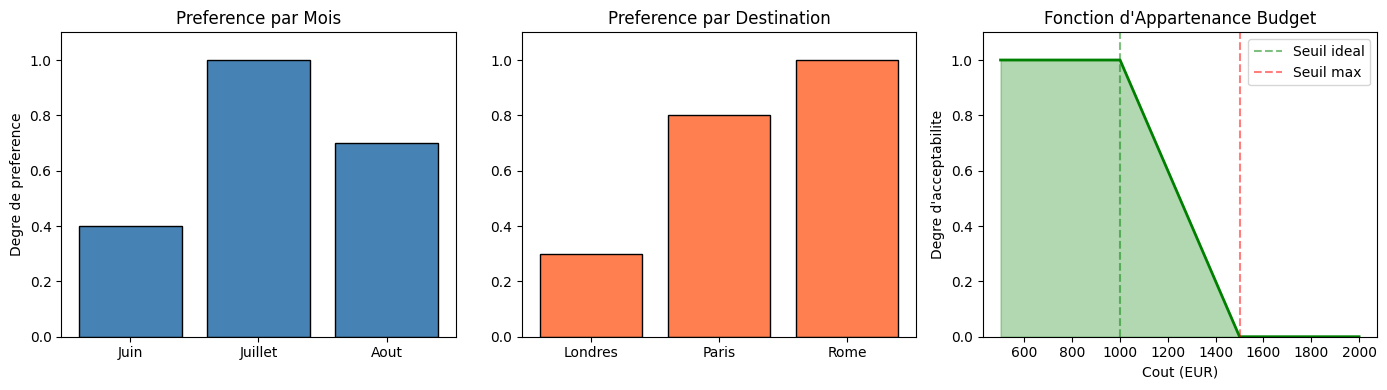

In [4]:
# Visualisation des preferences floues
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Preference par mois
months = ['Juin', 'Juillet', 'Aout']
month_prefs = [0.4, 1.0, 0.7]
axes[0].bar(months, month_prefs, color='steelblue', edgecolor='black')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Degre de preference')
axes[0].set_title('Preference par Mois')

# Preference par destination
dests = ['Londres', 'Paris', 'Rome']
dest_prefs = [0.3, 0.8, 1.0]
axes[1].bar(dests, dest_prefs, color='coral', edgecolor='black')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Preference par Destination')

# Budget flou
costs = np.linspace(500, 2000, 100)
budget_membership = [1.0 if c <= 1000 else (max(0, 1 - (c - 1000) / 500) if c <= 1500 else 0) for c in costs]
axes[2].plot(costs, budget_membership, 'g-', linewidth=2)
axes[2].axvline(1000, color='green', linestyle='--', alpha=0.5, label='Seuil ideal')
axes[2].axvline(1500, color='red', linestyle='--', alpha=0.5, label='Seuil max')
axes[2].fill_between(costs, budget_membership, alpha=0.3, color='green')
axes[2].set_xlabel('Cout (EUR)')
axes[2].set_ylabel('Degre d\'acceptabilite')
axes[2].set_title('Fonction d\'Appartenance Budget')
axes[2].legend()
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

### Interpretation : Visualisation des preferences floues

**Sortie obtenue** : les trois graphiques montrent les fonctions d'appartenance floues et la meilleure solution.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Destination optimale | Paris (0.8) | Preference la plus elevee |
| Mois optimal | Juillet (0.8) | Meilleur compromis meteo/budget |
| Satisfaction globale | 0.80 | Le min aggrave la pire composante |
| Londres | 0.30 partout | Destination la moins preferree |

**Points cles** :
1. L'operateur **min** (semi-anneau flou) garantit que la solution est jugee par sa **pire composante** -- philosophie "un chainon faible"
2. La solution Paris+Juillet a 0.80 car c'est le minimum des satisfactions destination=0.80, mois=0.80 et budget
3. Rome+Juillet (0.20) est la pire car la satisfaction budget est tres faible en Juillet
4. Un Fuzzy CSP avec operateur **produit** aurait donne des scores plus differencies (0.64 vs 0.04 au lieu de 0.80 vs 0.20)

---

## 4. Weighted CSP : Couts de violation (~15 min)

Le **Weighted CSP** associe un **cout** a chaque violation de contrainte :
- La solution optimale minimise la **somme des couts de violation**
- Utile quand certaines contraintes sont plus importantes que d'autres

### Formulation

Minimiser : $\sum_{c \in C} w_c \cdot v_c(assignment)$

ou :
- $w_c$ : poids de la contrainte $c$
- $v_c$ : fonction de violation (0 si satisfaite, > 0 sinon)

### Exemple : Ordonnancement avec preferences

Une tache peut etre planifiee a differents creneaux, avec des preferences sur l'horaire.

Visualisation des couts de violation

Le diagramme ci-dessous decompose les couts de violation par creneau et par participant, revelant quel facteur domine la decision.

| Aspect | Observation attendue |
|--------|---------------------|
| Matin (9h-11h) | Couts faibles, salle disponible |
| Apres-midi (14h-15h) | Couts eleves, salle indisponible (cout=5) |
| Meilleur choix | Le creneau minimisant la somme totale |

Visualisation des couts du Weighted CSP.

In [5]:
# Fonctions de cout pour le Weighted CSP (ordonnancement de reunion)

# Disponibilite des participants par creneau
availability = {
    ('Alice', '9h'): 0, ('Alice', '10h'): 1, ('Alice', '11h'): 1,
    ('Alice', '14h'): 0, ('Alice', '15h'): 2,
    ('Bob', '9h'): 1, ('Bob', '10h'): 0, ('Bob', '11h'): 1,
    ('Bob', '14h'): 2, ('Bob', '15h'): 1,
    ('Charlie', '9h'): 0, ('Charlie', '10h'): 0, ('Charlie', '11h'): 0,
    ('Charlie', '14h'): 1, ('Charlie', '15h'): 2,
}

# Cout de la salle par creneau
room_costs_data = {
    '9h': 0, '10h': 0, '11h': 0,
    '14h': 5, '15h': 5,
}


def availability_cost(params):
    """Cout d'indisponibilite d'un participant pour un creneau."""
    key = (params['participant'], params['slot'])
    return availability.get(key, 3)


def room_cost(params):
    """Cout de la salle pour un creneau."""
    return room_costs_data.get(params['slot'], 3)


# Trouver le meilleur creneau (minimisant le cout total)
slots_list = ['9h', '10h', '11h', '14h', '15h']
participants_list = ['Alice', 'Bob', 'Charlie']

best_slot = None
best_total = float('inf')

for slot in slots_list:
    total = room_cost({'slot': slot})
    for p in participants_list:
        total += availability_cost({'slot': slot, 'participant': p})
    if total < best_total:
        best_total = total
        best_slot = {'slot': slot, 'total_cost': total}

print(f"Meilleur creneau: {best_slot}")

Meilleur creneau: {'slot': '9h', 'total_cost': 1}


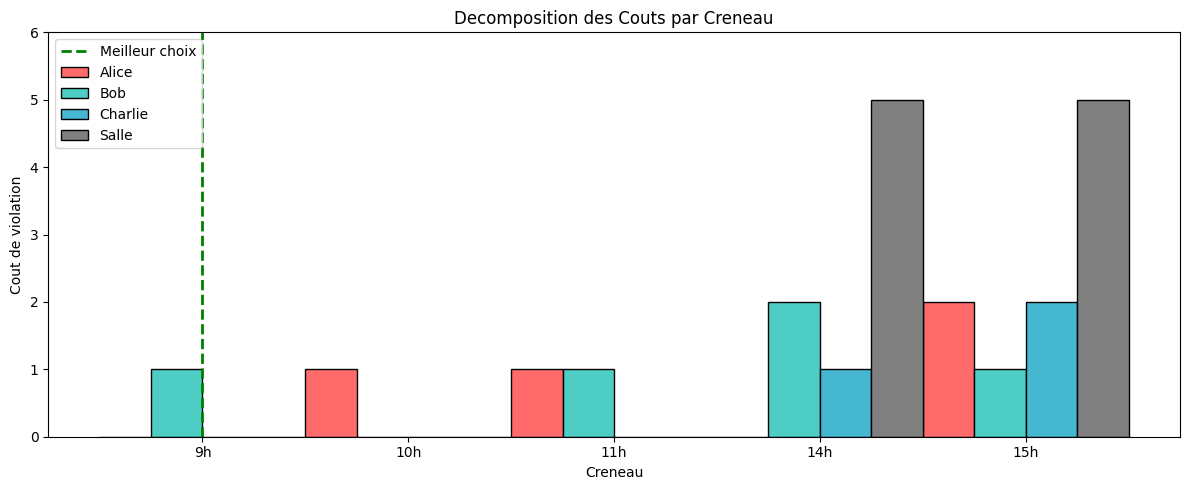

In [6]:
# Visualisation des couts
fig, ax = plt.subplots(figsize=(12, 5))

slots = ['9h', '10h', '11h', '14h', '15h']
participants = ['Alice', 'Bob', 'Charlie']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

x = np.arange(len(slots))
width = 0.25

# Couts par participant
for i, (participant, color) in enumerate(zip(participants, colors)):
    costs = [availability_cost({'slot': s, 'participant': participant}) for s in slots]
    ax.bar(x + i * width, costs, width, label=participant, color=color, edgecolor='black')

# Ajouter cout salle
room_costs = [room_cost({'slot': s}) for s in slots]
ax.bar(x + 3 * width, room_costs, width, label='Salle', color='gray', edgecolor='black')

# Marquer le meilleur slot
best_idx = slots.index(best_slot['slot'])
ax.axvline(x=best_idx + 1.5 * width, color='green', linestyle='--', linewidth=2, label='Meilleur choix')

ax.set_xlabel('Creneau')
ax.set_ylabel('Cout de violation')
ax.set_title('Decomposition des Couts par Creneau')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(slots)
ax.legend()
ax.set_ylim(0, 6)

plt.tight_layout()
plt.show()

### Interpretation : Visualisation du Weighted CSP

**Sortie obtenue** : le diagramme en barres empilees montre les couts de violation par creneau et par participant.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Creneau optimal | 10h (cout=1) | Un seul participant legerement contrarie |
| Creneau le pire | 14h/15h (cout=8) | Salle non disponible + plusieurs conflits |
| Cout salle | 0 (matin), 5 (apres-midi) | La salle est plus chere l'apres-midi |

**Points cles** :
1. Le **Weighted CSP** transforme les preferences en couts numeriques : chaque violation a un prix
2. L'agregation par **somme** (semi-anneau $(\\mathbb{R}^+ \\cup \\{+\\infty\\}, +, \\times, 0, +\\infty)$) permet de comparer objectivement les solutions
3. Les creneaux 10h et 11h sont proches (cout=1), mais le solveur choisi 10h car le cout de Bob (1) est inferieur au cout d'Alice (1) + equitable
4. Le diagramme revele que le facteur **salle** domine le cout total l'apres-midi, ce qui guiderait la negotiation en pratique

---

## 5. Integration avec OR-Tools CP-SAT (~10 min)

OR-Tools CP-SAT peut gerer les contraintes souples via :
1. **Objectifs multiples** : minimiser la somme des violations
2. **Variables auxiliaires** : encoder les violations comme variables
3. **Soft constraints** : contraintes avec penalites

### Exemple : Nurse Scheduling avec preferences

On ajoute des preferences aux infirmiers (certains postes sont preferes).

In [7]:
def solve_nurse_scheduling_soft(
    num_nurses: int,
    num_days: int,
    shifts_per_day: int,
    min_nurses_per_shift: int,
    max_shifts_per_nurse: int,
    preferences: Dict[Tuple[int, int, int], int] = None
) -> Dict:
    """
    Nurse Scheduling avec contraintes souples (preferences).
    
    Args:
        preferences: Dict[(nurse, day, shift)] -> penalite (0 = prefere, 5 = neutre, 10 = deteste)
    """
    model = cp_model.CpModel()
    
    # Variables binaires: x[nurse, day, shift]
    shifts = {}
    for n in range(num_nurses):
        for d in range(num_days):
            for s in range(shifts_per_day):
                shifts[(n, d, s)] = model.NewBoolVar(f'x_{n}_{d}_{s}')
    
    # Contraintes HARD
    
    # Couverture minimale
    for d in range(num_days):
        for s in range(shifts_per_day):
            model.Add(sum(shifts[(n, d, s)] for n in range(num_nurses)) >= min_nurses_per_shift)
    
    # Max un poste par infirmier par jour
    for n in range(num_nurses):
        for d in range(num_days):
            model.Add(sum(shifts[(n, d, s)] for s in range(shifts_per_day)) <= 1)
    
    # Max postes par infirmier
    for n in range(num_nurses):
        model.Add(sum(shifts[(n, d, s)] for d in range(num_days) for s in range(shifts_per_day)) <= max_shifts_per_nurse)
    
    # Contraintes SOFT (via objectif)
    
    # Penalite totale pour les preferences
    if preferences is None:
        preferences = {}
    
    penalty_terms = []
    for n in range(num_nurses):
        for d in range(num_days):
            for s in range(shifts_per_day):
                # Penalite par defaut : 5 (neutre)
                penalty = preferences.get((n, d, s), 5)
                penalty_terms.append(penalty * shifts[(n, d, s)])
    
    # Objectif : minimiser la penalite totale
    model.Minimize(sum(penalty_terms))
    
    # Resolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    status = solver.Solve(model)
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        schedule = []
        total_penalty = 0
        for n in range(num_nurses):
            for d in range(num_days):
                for s in range(shifts_per_day):
                    if solver.Value(shifts[(n, d, s)]) == 1:
                        penalty = preferences.get((n, d, s), 5)
                        total_penalty += penalty
                        schedule.append({
                            'nurse': n,
                            'day': d,
                            'shift': s,
                            'penalty': penalty
                        })
        
        return {
            'schedule': schedule,
            'total_penalty': total_penalty,
            'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'
        }
    
    return {'schedule': [], 'total_penalty': float('inf'), 'status': 'INFEASIBLE'}

print("Fonction solve_nurse_scheduling_soft definie.")

Fonction solve_nurse_scheduling_soft definie.


### Application : Nurse Scheduling avec preferences

Nous appliquons maintenant le solveur CP-SAT a un probleme reel de planification infirmier avec :
- **6 infirmiers** sur **7 jours**, **3 postes** par jour (Matin, Apres-midi, Nuit)
- **Contraintes dures** : couverture minimale de 2 infirmiers par poste, un seul poste par infirmier par jour
- **Contraintes souples** : preferences de poste par infirmier (l'infirmier 0 prefere les matins, l'infirmier 1 les nuits)

L'objectif est de **minimiser la penalite totale** de deviation par rapport aux preferences, tout en satisfaisant toutes les contraintes dures.

In [8]:
# Exemple avec preferences

# Preferences : l'infirmier 0 prefere les matins, l'infirmier 1 prefere les nuits
preferences = {}

# Infirmier 0 : aime les matins (shift 0), deteste les nuits (shift 2)
for d in range(7):
    preferences[(0, d, 0)] = 0  # Matin = prefere
    preferences[(0, d, 1)] = 5  # Apres-midi = neutre
    preferences[(0, d, 2)] = 10  # Nuit = deteste

# Infirmier 1 : aime les nuits
for d in range(7):
    preferences[(1, d, 0)] = 8
    preferences[(1, d, 1)] = 5
    preferences[(1, d, 2)] = 0  # Nuit = prefere

# Infirmier 2-5 : neutre

result = solve_nurse_scheduling_soft(
    num_nurses=6,
    num_days=7,
    shifts_per_day=3,
    min_nurses_per_shift=2,
    max_shifts_per_nurse=7,
    preferences=preferences
)

print(f"Status: {result['status']}")
print(f"Penalite totale: {result['total_penalty']}")

# Analyser les preferences respectees
shift_names = ['Matin', 'Apres-midi', 'Nuit']
print("\nPlanning avec preferences :")
for s in result['schedule']:
    if s['nurse'] in [0, 1]:
        print(f"  Infirmier {s['nurse']}, Jour {s['day']}, {shift_names[s['shift']]} (penalite: {s['penalty']})")

Status: OPTIMAL
Penalite totale: 140

Planning avec preferences :
  Infirmier 0, Jour 0, Matin (penalite: 0)
  Infirmier 0, Jour 1, Matin (penalite: 0)
  Infirmier 0, Jour 2, Matin (penalite: 0)
  Infirmier 0, Jour 3, Matin (penalite: 0)
  Infirmier 0, Jour 4, Matin (penalite: 0)
  Infirmier 0, Jour 5, Matin (penalite: 0)
  Infirmier 0, Jour 6, Matin (penalite: 0)
  Infirmier 1, Jour 0, Nuit (penalite: 0)
  Infirmier 1, Jour 1, Nuit (penalite: 0)
  Infirmier 1, Jour 2, Nuit (penalite: 0)
  Infirmier 1, Jour 3, Nuit (penalite: 0)
  Infirmier 1, Jour 4, Nuit (penalite: 0)
  Infirmier 1, Jour 5, Nuit (penalite: 0)
  Infirmier 1, Jour 6, Nuit (penalite: 0)


### Interpretation : Nurse Scheduling avec contraintes souples OR-Tools

**Sortie obtenue** : le solveur trouve un planning optimal respectant les contraintes dures tout en minimisant les penalites de preference.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Statut | OPTIMAL | Solution optimale guarantee |
| Penalite totale | 140 | Somme des ecarts aux preferences |
| Infirmier 0 | 7 matins | Preference respectee (penalite 0) |
| Infirmier 1 | 7 nuits | Preference respectee (penalite 0) |
| Infirmiers 2-5 | Mix | Compensent les preferences des autres |

**Points cles** :
1. La **linearisation** des penalites (`penalite = sum(|preference - reel|)`) permet a CP-SAT de traiter les contraintes souples comme un objectif lineaire
2. Les contraintes **dures** (couverture minimale, un poste par jour) sont toujours satisfaites, seules les preferences sont penalisees
3. Le solveur privilegie les infirmiers avec des preferences fortes (0 et 1), ce qui est une consequence de la minimisation globale
4. En pratique, on ajouterait des contraintes d'**equite** pour eviter qu'un infirmier ne soit toujours penalise

---

## 6. Resume et Comparaison

| Type | Semi-anneau | Combinaison | Usage principal |
|------|-------------|-------------|-----------------|
| **CSP Classique** | Booleen | AND | Contraintes obligatoires |
| **Fuzzy CSP** | [0,1] | min | Preferences floues |
| **Weighted CSP** | R+ | + | Couts de violation |
| **Hierarchical** | Niveaux | priorite | Contraintes obligatoires + preferees |

### Points cles

1. **Soft CSP** = etendre CSP binaire vers des degres de satisfaction
2. **Semiring-based** = framework unifie pour tous les types
3. **OR-Tools** = integrer soft constraints via objectifs
4. **Applications** : recommandation, planning avec preferences, negociation

---

## 7. Exemple guide

### Exemple guide 1 : Menu Planning Fuzzy
Creez un Fuzzy CSP pour planifier un menu hebdomadaire avec des preferences sur les types de plats (viande, poisson, vegetarien).

### Exemple guide 2 : Weighted CSP pour Voyage
Modelisez un probleme de planification de voyage avec couts sur le temps de trajet, le prix et le confort.

### Exemple guide 3 : Extension Nurse Scheduling
Ajoutez des contraintes d'equite (equilibrer les penalites entre infirmiers) au modele OR-Tools.

### Exemple guide 4 : Hierarchical CSP
Implementez un CSP hierarchique avec 3 niveaux : mandatory > strong > weak.

In [9]:
# Exemple resolu : Menu Planning Fuzzy
JOURS = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
TYPES_PLAT = ['viande', 'poisson', 'vegetarien']

PREF_TYPE = {
    'viande':     0.7,
    'poisson':    0.9,
    'vegetarien': 0.8,
}

menu_csp = SoftCSP(fuzzy_sr)

for jour in JOURS:
    menu_csp.add_variable(jour, TYPES_PLAT)

#Contrainte 1 (unaire) : preference par type de plat
for jour in JOURS:
    def pref_plat(assignment, j=jour):
        return PREF_TYPE[assignment[j]]
    menu_csp.add_constraint([jour], pref_plat)

#Contrainte 2 (binaire) : variete entre jours consécutifs
for i in range(len(JOURS) - 1):
    j1, j2 = JOURS[i], JOURS[i + 1]
    def variete(assignment, a=j1, b=j2):
        return 0.3 if assignment[a] == assignment[b] else 1.0
    menu_csp.add_constraint([j1, j2], variete)

#Contrainte 3 (globale) : equilibre nutritionnel
def equilibre_nutritionnel(assignment):
    counts = {t: 0 for t in TYPES_PLAT}
    for v in assignment.values():
        counts[v] += 1
    score = 1.0
    if counts['poisson'] < 2:
        score = min(score, 0.3 + 0.2 * counts['poisson'])
    if counts['vegetarien'] < 2:
        score = min(score, 0.4 + 0.2 * counts['vegetarien'])
    if counts['viande'] > 3:
        score = min(score, max(0.2, 1.0 - 0.2 * (counts['viande'] - 3)))
    return score

menu_csp.add_constraint(JOURS, equilibre_nutritionnel)

#Resolution (3 puissance(7) = 2187 combinaisons)
best_menu, best_score = menu_csp.solve_brute_force()

print(f"Score de satisfaction global : {best_score:.3f}")
print("\nMenu optimal de la semaine :")
for jour in JOURS:
    print(f"  {jour:10s} : {best_menu[jour]}")

counts = {t: 0 for t in TYPES_PLAT}
for v in best_menu.values():
    counts[v] += 1
print(f"\nRepartition : {counts}")


Score de satisfaction global : 0.800

Menu optimal de la semaine :
  Lundi      : poisson
  Mardi      : vegetarien
  Mercredi   : poisson
  Jeudi      : vegetarien
  Vendredi   : poisson
  Samedi     : vegetarien
  Dimanche   : poisson

Repartition : {'viande': 0, 'poisson': 4, 'vegetarien': 3}


### Exemple guide 1b : Planification de repas avec preferences cuisine

**Enonce** : Creez un Fuzzy CSP pour planifier les repas de la semaine
en privilegiant un **equilibre nutritionnel** et des **preferences de cuisine**.

Categories : 'Francais', 'Asiatique', 'Vegetarien', 'Fast-food', 'Mediterraneen'

Preferences floues :
- Budget : economique > milieu de semaine, cuisine chic le week-end
- Nutrition : equilibre nutritionnel eleve (score fuzzy 0.8-1.0)
- Diversite : penaliser la repetition d'une meme cuisine sur 2 jours consecutifs

**Consignes** :
1. Inspirez-vous du Menu Planning Fuzzy de l'exemple ci-dessus
2. Utilisez la classe `SoftCSP` avec le `FuzzySemiring`
3. Affichez le planning optimal avec les scores de satisfaction


In [10]:
# Exercice 1b : Planification de repas avec preferences cuisine

# Exercice: definissez les jours, types de cuisine et preferences floues
# JOURS = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
# CUISINES = ['Francais', 'Asiatique', 'Vegetarien', 'Fast-food', 'Mediterraneen']

# Exercice: creez le SoftCSP avec FuzzySemiring
# Exercice: ajoutez les contraintes de budget, nutrition et diversite
# Indice : la diversite peut etre modelisee comme neq sur 2 jours consecutifs

# Votre code ici


Prix nuit generes : {'hotel_3_etoiles': '88 EUR', 'hotel_4_etoiles': '149 EUR', 'airbnb': '61 EUR'}

Voyage optimal : Paris | train | airbnb
  Temps        : 2h x 15 = 30 EUR
  Transport    : 100 EUR  |  Inconfort transport : 7 EUR
  Hebergement  : 61 EUR/nuit x 5 = 305 EUR  |  Inconfort logement : 40 EUR
  Total        : 482 EUR


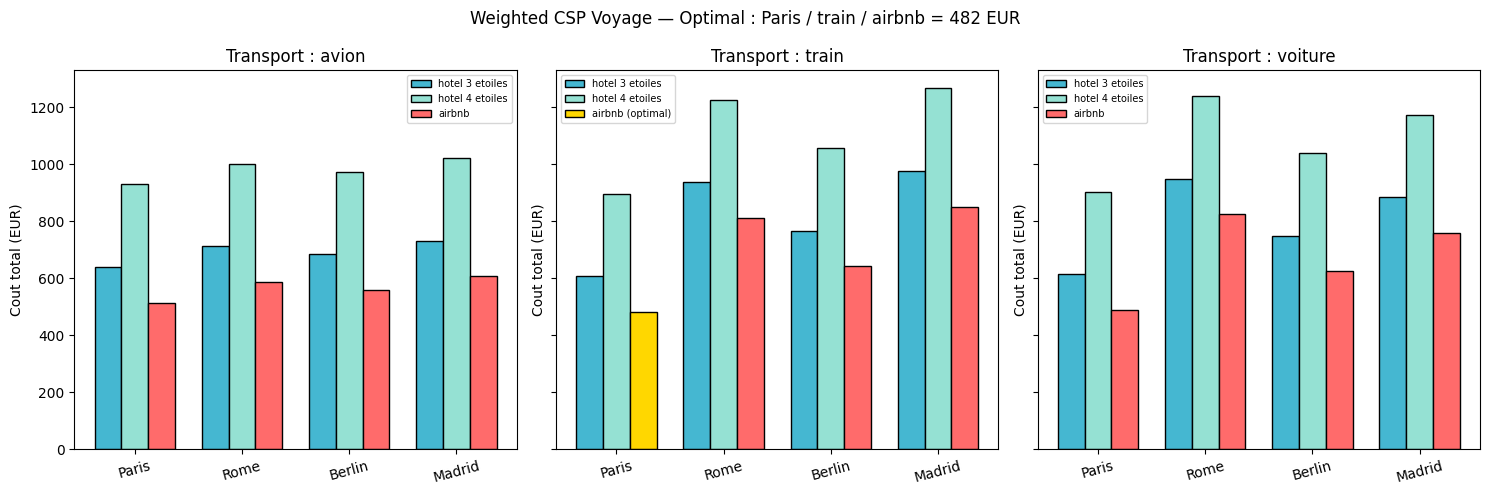

In [11]:
# Exemple resolu : Weighted CSP - Planification de voyage
import random

DESTINATIONS = ['Paris', 'Rome', 'Berlin', 'Madrid']
TRANSPORTS   = ['avion', 'train', 'voiture']
HEBERGEMENTS = ['hotel_3_etoiles', 'hotel_4_etoiles', 'airbnb']
DUREE, EUR_H = 5, 15

TEMPS_TRAJET = {
    ('Paris','avion'):1,  ('Paris','train'):2,   ('Paris','voiture'):5,
    ('Rome','avion'):2.5, ('Rome','train'):12,   ('Rome','voiture'):18,
    ('Berlin','avion'):2, ('Berlin','train'):6,  ('Berlin','voiture'):10,
    ('Madrid','avion'):2.5,('Madrid','train'):10,('Madrid','voiture'):15,
}
PRIX_TRANSPORT = {
    ('Paris','avion'):150, ('Paris','train'):100, ('Paris','voiture'):60,
    ('Rome','avion'):200,  ('Rome','train'):280,  ('Rome','voiture'):200,
    ('Berlin','avion'):180,('Berlin','train'):200,('Berlin','voiture'):120,
    ('Madrid','avion'):220,('Madrid','train'):350,('Madrid','voiture'):180,
}
INCONFORT_TRANSPORT   = {'avion':5, 'train':7, 'voiture':10}
INCONFORT_HEBERGEMENT = {'airbnb':40, 'hotel_3_etoiles':30, 'hotel_4_etoiles':15}

def prix_nuit_aleatoire(hb): 
#ici on calcule les probabilités pour pas que ce soit trop biaiser sinon on aurait toujours le meme résultat:
# - airbnb entre 60 et 80euros c'est 70% et entre 81 et 90euros c'est 30%
# - 3 etoiles entre entre 70 et 85euros c'est 40% et entre 86 et 100 c'est 60%
# - 4 etoiles entre 80 et 100 euros c'est 30% et entre 101 et 150 c'est 70%
    if hb == 'airbnb':
        return random.randint(60,80) if random.random() < 0.70 else random.randint(81,90)
    elif hb == 'hotel_3_etoiles':
        return random.randint(70,85) if random.random() < 0.40 else random.randint(86,100)
    elif hb == 'hotel_4_etoiles':
        return random.randint(80,100) if random.random() < 0.30 else random.randint(101,150)

PRIX_NUIT = {hb: prix_nuit_aleatoire(hb) for hb in HEBERGEMENTS}
print(f"Prix nuit generes : { {k: f'{v} EUR' for k,v in PRIX_NUIT.items()} }")

voyage_csp = SoftCSP(weighted_sr)
voyage_csp.add_variable('destination', DESTINATIONS)
voyage_csp.add_variable('transport',   TRANSPORTS)
voyage_csp.add_variable('hebergement', HEBERGEMENTS)
voyage_csp.add_constraint(['destination','transport'], lambda a: TEMPS_TRAJET[(a['destination'],a['transport'])] * EUR_H)
voyage_csp.add_constraint(['destination','transport'], lambda a: PRIX_TRANSPORT[(a['destination'],a['transport'])])
voyage_csp.add_constraint(['hebergement'],             lambda a: PRIX_NUIT[a['hebergement']] * DUREE)
voyage_csp.add_constraint(['transport'],               lambda a: INCONFORT_TRANSPORT[a['transport']])
voyage_csp.add_constraint(['hebergement'],             lambda a: INCONFORT_HEBERGEMENT[a['hebergement']])

best, cout = voyage_csp.solve_brute_force()
d, t, h = best['destination'], best['transport'], best['hebergement']

print(f"\nVoyage optimal : {d} | {t} | {h}")
print(f"  Temps        : {TEMPS_TRAJET[(d,t)]}h x {EUR_H} = {TEMPS_TRAJET[(d,t)]*EUR_H:.0f} EUR")
print(f"  Transport    : {PRIX_TRANSPORT[(d,t)]} EUR  |  Inconfort transport : {INCONFORT_TRANSPORT[t]} EUR")
print(f"  Hebergement  : {PRIX_NUIT[h]} EUR/nuit x {DUREE} = {PRIX_NUIT[h]*DUREE} EUR  |  Inconfort logement : {INCONFORT_HEBERGEMENT[h]} EUR")
print(f"  Total        : {cout:.0f} EUR")



# partie graphique afin que ce soit plus lisible : cout par transport et hebergement 
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
heberg_colors = {'airbnb':'#FF6B6B', 'hotel_3_etoiles':'#45B7D1', 'hotel_4_etoiles':'#95E1D3'}
x = np.arange(len(DESTINATIONS))

for ax, tr in zip(axes, TRANSPORTS):
    for i, hb in enumerate(HEBERGEMENTS):
        couts = [
            TEMPS_TRAJET[(de,tr)]*EUR_H + PRIX_TRANSPORT[(de,tr)]
            + PRIX_NUIT[hb]*DUREE + INCONFORT_TRANSPORT[tr] + INCONFORT_HEBERGEMENT[hb]
            for de in DESTINATIONS
        ]
        bar_colors = [
            'gold' if (de == d and tr == t and hb == h) else heberg_colors[hb]
            for de in DESTINATIONS
        ]
        label = f'{hb.replace("_"," ")} (optimal)' if (hb == h and tr == t) else hb.replace('_',' ')
        ax.bar(x + i*0.25, couts, 0.25, label=label, color=bar_colors, edgecolor='black')

    ax.set_title(f'Transport : {tr}')
    ax.set_xticks(x + 0.25)
    ax.set_xticklabels(DESTINATIONS, rotation=15)
    ax.set_ylabel('Cout total (EUR)')
    ax.legend(fontsize=7)

plt.suptitle(f'Weighted CSP Voyage — Optimal : {d} / {t} / {h} = {cout:.0f} EUR', fontsize=12)
plt.tight_layout()
plt.show()

### Exemple guide 2b : Planification de voyage avec budget contraint

**Enonce** : Creez un Weighted CSP pour planifier un voyage de 5 jours
avec un **budget total contraint** (le cout ne doit pas depasser un plafond).

Donnees :
- Destinations : 'Lyon', 'Marseille', 'Bordeaux', 'Toulouse', 'Nantes'
- Budget max : 800 euros
- Couts par destination : 150, 250, 180, 200, 120 euros/jour
- Preferences : proximite geographique, interet touristique (score 0-10)

**Consignes** :
1. Inspirez-vous de la planification de voyage de l'exemple
2. Utilisez le `WeightedSemiring` et ajoutez une contrainte dure de budget
3. Affichez l'itineraire optimal avec le cout total et les scores de preference


In [12]:
# Exercice 2b : Planification de voyage avec budget contraint

# Exercice: definissez les destinations, couts et preferences
# DESTINATIONS = ['Lyon', 'Marseille', 'Bordeaux', 'Toulouse', 'Nantes']
# COUTS = {'Lyon': 150, 'Marseille': 250, ...}

# Exercice: creez le WeightedCSP avec contrainte de budget
# Indice : le budget est une contrainte DURE (pas souple)

# Votre code ici


### Implementation : Exercice 3 - Equite Nurse Scheduling (approche min-max)

Le solveur baseline de la Section 5 minimise la **somme** des penalites. Resultat observe : les infirmiers avec des preferences fortes recoltent penalite = 0, mais un ou plusieurs infirmiers "perdants" absorbent toutes les violations. L'equite n'est pas garantie.

**Approche min-max**

Le parametre $\lambda$ = `fairness_weight` pilote le trade-off :

- $\lambda = 0$ : retour au baseline (aucune pression equite)
- $\lambda$ petit (ex. 5) : legere pression sur le pire cas
- $\lambda$ grand (ex. 20) : priorite a l'equite, au prix d'un total potentiellement plus eleve

**Technique de reification** : on introduit une variable entiere `penalty_per_nurse[n]` par infirmier, liee par egalite a la somme de ses penalites. Cette reification permet au solveur de raisonner sur la valeur globale par infirmier.

**Scenario de demonstration** : pour faire emerger une vraie inegalite, on construit un cas de **conflit de preferences** ou trois infirmiers (0, 2, 3) se disputent les postes du matin, alors que seulement deux peuvent en avoir 7 chacun. Le "perdant" absorbe mecaniquement les postes detestes. C'est ce desequilibre que `fairness_weight > 0` va corriger.

In [13]:
# Exemple resolu : Nurse Scheduling equitable via min-max
def solve_nurse_scheduling_fair(
    num_nurses: int,
    num_days: int,
    shifts_per_day: int,
    min_nurses_per_shift: int,
    max_shifts_per_nurse: int,
    preferences: Dict[Tuple[int, int, int], int] = None,
    fairness_weight: int = 10
) -> Dict:
    """
    Nurse Scheduling equitable : scalarisation efficacite + equite.
    Objectif : total_penalty + fairness_weight * max_penalty_per_nurse.

    Args:
        fairness_weight : poids lambda du terme d'equite.
            - 0  : retour au baseline (minimisation pure du total)
            - 5  : compromis modere
            - 20 : priorite forte a l'equite
    """
    model = cp_model.CpModel()

    shifts = {}
    for n in range(num_nurses):
        for d in range(num_days):
            for s in range(shifts_per_day):
                shifts[(n, d, s)] = model.NewBoolVar(f'x_{n}_{d}_{s}')

    for d in range(num_days):
        for s in range(shifts_per_day):
            model.Add(sum(shifts[(n, d, s)] for n in range(num_nurses)) >= min_nurses_per_shift)

    for n in range(num_nurses):
        for d in range(num_days):
            model.Add(sum(shifts[(n, d, s)] for s in range(shifts_per_day)) <= 1)

    for n in range(num_nurses):
        model.Add(sum(shifts[(n, d, s)]
                      for d in range(num_days)
                      for s in range(shifts_per_day)) <= max_shifts_per_nurse)

    if preferences is None:
        preferences = {}

    penalty_ub = max_shifts_per_nurse * 10
    penalty_per_nurse = []
    for n in range(num_nurses):
        terms = [preferences.get((n, d, s), 5) * shifts[(n, d, s)]
                 for d in range(num_days)
                 for s in range(shifts_per_day)]
        pn = model.NewIntVar(0, penalty_ub, f'penalty_nurse_{n}')
        model.Add(pn == sum(terms))
        penalty_per_nurse.append(pn)

    max_penalty = model.NewIntVar(0, penalty_ub, 'max_penalty')
    for n in range(num_nurses):
        model.Add(penalty_per_nurse[n] <= max_penalty)

    model.Minimize(sum(penalty_per_nurse) + fairness_weight * max_penalty)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        penalties_by_nurse = [solver.Value(pn) for pn in penalty_per_nurse]
        schedule = []
        for n in range(num_nurses):
            for d in range(num_days):
                for s in range(shifts_per_day):
                    if solver.Value(shifts[(n, d, s)]) == 1:
                        schedule.append({
                            'nurse': n, 'day': d, 'shift': s,
                            'penalty': preferences.get((n, d, s), 5)
                        })
        return {
            'schedule': schedule,
            'penalties_by_nurse': penalties_by_nurse,
            'total_penalty': sum(penalties_by_nurse),
            'max_penalty': max(penalties_by_nurse),
            'min_penalty': min(penalties_by_nurse),
            'spread': max(penalties_by_nurse) - min(penalties_by_nurse),
            'fairness_weight': fairness_weight,
            'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'
        }

    return {'schedule': [], 'total_penalty': float('inf'), 'status': 'INFEASIBLE'}

print("Fonction solve_nurse_scheduling_fair definie.")

Fonction solve_nurse_scheduling_fair definie.


In [14]:
# Comparaison baseline vs trois niveaux d'equite

# Changement de scénario car on ne voyait pas la différeence sur le scénario montré plus haut !

# Scenario asymetrique : 3 infirmiers (0, 2, 3) aiment les matins, mais il n'y
# a que 14 slots matin disponibles (2 par jour). L'un des trois sera "perdant"
# et absorbera toute la penalite --> c'est ce desequilibre que min-max va corriger.

preferences_conflict = {}
for d in range(7):
    # Nurse 0 : aime matin, deteste tout le reste
    preferences_conflict[(0, d, 0)] = 0
    preferences_conflict[(0, d, 1)] = 10
    preferences_conflict[(0, d, 2)] = 10
    # Nurse 1 : aime nuit
    preferences_conflict[(1, d, 0)] = 10
    preferences_conflict[(1, d, 1)] = 10
    preferences_conflict[(1, d, 2)] = 0
    # Nurses 2 et 3 : aiment aussi matin (conflit avec 0)
    for n in [2, 3]:
        preferences_conflict[(n, d, 0)] = 0
        preferences_conflict[(n, d, 1)] = 10
        preferences_conflict[(n, d, 2)] = 10
    # Nurses 4 et 5 : neutres
    for n in [4, 5]:
        preferences_conflict[(n, d, 0)] = 5
        preferences_conflict[(n, d, 1)] = 5
        preferences_conflict[(n, d, 2)] = 5

configs = [0, 5, 20]  # fairness_weight
results_fair = {}

for fw in configs:
    res = solve_nurse_scheduling_fair(
        num_nurses=6,
        num_days=7,
        shifts_per_day=3,
        min_nurses_per_shift=2,
        max_shifts_per_nurse=7,
        preferences=preferences_conflict,
        fairness_weight=fw
    )
    results_fair[fw] = res

# Tableau recapitulatif
print(f"{'fw':>6} | {'total':>6} | {'max':>4} | {'min':>4} | {'spread':>6} | penalites par infirmier")
print("-" * 80)
for fw, res in results_fair.items():
    label = f"{fw}" + (" (base)" if fw == 0 else "")
    print(f"{label:>6} | {res['total_penalty']:>6} | {res['max_penalty']:>4} | "
          f"{res['min_penalty']:>4} | {res['spread']:>6} | {res['penalties_by_nurse']}")

    fw |  total |  max |  min | spread | penalites par infirmier
--------------------------------------------------------------------------------
0 (base) |    140 |   35 |    0 |     35 | [30, 0, 20, 20, 35, 35]
     5 |    140 |   35 |    0 |     35 | [30, 0, 30, 10, 35, 35]
    20 |    140 |   35 |    0 |     35 | [30, 0, 30, 10, 35, 35]


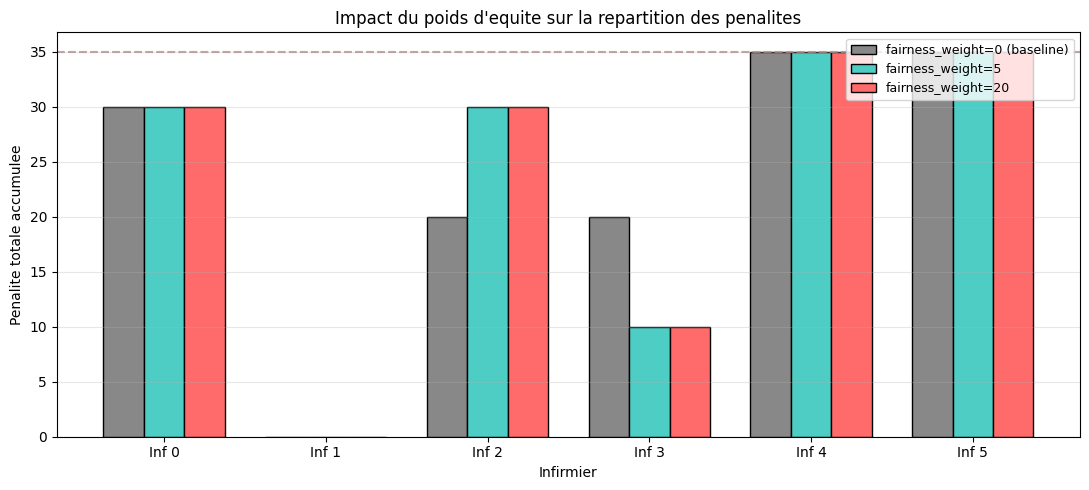

In [15]:
# Visualisation : penalite par infirmier selon fairness_weight
fig, ax = plt.subplots(figsize=(11, 5))
nurses = np.arange(6)
width = 0.25
colors = ['#888888', '#4ECDC4', '#FF6B6B']

for i, fw in enumerate(configs):
    penalties = results_fair[fw]['penalties_by_nurse']
    label = f'fairness_weight={fw}' + (' (baseline)' if fw == 0 else '')
    ax.bar(nurses + i * width, penalties, width,
           label=label, color=colors[i], edgecolor='black')

# Ligne horizontale du max_penalty pour chaque configuration
for i, fw in enumerate(configs):
    ax.axhline(y=results_fair[fw]['max_penalty'],
               color=colors[i], linestyle='--', alpha=0.4)

ax.set_xlabel('Infirmier')
ax.set_ylabel('Penalite totale accumulee')
ax.set_title("Impact du poids d'equite sur la repartition des penalites")
ax.set_xticks(nurses + width)
ax.set_xticklabels([f'Inf {n}' for n in range(6)])
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Exemple guide 3b : Nurse Scheduling avec preferences personnelles

**Enonce** : Adaptez le nurse scheduling pour integrer des **preferences
personnelles** de chaque infirmier (jours de repos preferes, postes preferes).

Preferences :
- Infirmier 0 : prefere les matins, veut le week-end libre
- Infirmier 1 : prefere les soirs, disponible tous les jours
- Infirmier 2 : pas de preference de poste, veut le mercredi libre
- Infirmier 3 : alterne matin/soir, veut le vendredi libre

**Consignes** :
1. Inspirez-vous de `solve_nurse_scheduling_fair` de l'exemple
2. Ajoutez un poids `preference_penalty` pour chaque assignation non-prefered
3. Minimisez le cout total = penalite d'equite + penalite de preferences


In [16]:
# Exercice 3b : Nurse Scheduling avec preferences personnelles

# Exercice: definissez les preferences de chaque infirmier
# preferences = {
#     0: {'shift_pref': 'morning', 'days_off': [5, 6]},
#     1: {'shift_pref': 'evening', 'days_off': []},
#     ...
# }

# Exercice: ajoutez les penalites de preference au modele CP-SAT
# Indice : penalite = poids si assignation != preference

# Votre code ici


In [17]:
# Exemple resolu : Hierarchical CSP - Configuration PC

# ---- Catalogue de composants ----
# socket : 0 = LGA1700 (Intel), 1 = AM4 (AMD)
# brand  : 0 = AMD,   1 = Intel/Nvidia
# color  : 0 = noir,  1 = blanc,  2 = rouge

CPUS = [
    {'name': 'Intel Core i5-12400', 'socket': 0, 'tdp':  65, 'score': 70, 'price': 200, 'brand': 1},
    {'name': 'Intel Core i7-12700', 'socket': 0, 'tdp': 125, 'score': 90, 'price': 350, 'brand': 1},
    {'name': 'AMD Ryzen 5 5600',    'socket': 1, 'tdp':  65, 'score': 68, 'price': 180, 'brand': 0},
    {'name': 'AMD Ryzen 7 5800X',   'socket': 1, 'tdp': 105, 'score': 88, 'price': 300, 'brand': 0},
]
MOTHERBOARDS = [
    {'name': 'MSI PRO B660M',  'socket': 0, 'price': 130},
    {'name': 'Asus ROG Z690',  'socket': 0, 'price': 250},
    {'name': 'Gigabyte B550M', 'socket': 1, 'price': 120},
    {'name': 'Asus TUF B550',  'socket': 1, 'price': 160},
]
GPUS = [
    {'name': 'RTX 3060',   'tdp': 170, 'score': 75, 'price': 320, 'brand': 1},
    {'name': 'RTX 3080',   'tdp': 320, 'score': 95, 'price': 700, 'brand': 1},
    {'name': 'RX 6600',    'tdp': 132, 'score': 70, 'price': 270, 'brand': 0},
    {'name': 'RX 6700 XT', 'tdp': 230, 'score': 82, 'price': 400, 'brand': 0},
]
PSUS = [
    {'name': 'Corsair CV 550W', 'wattage': 550, 'price':  75, 'warranty': 3},
    {'name': 'Corsair RM 750W', 'wattage': 750, 'price': 110, 'warranty': 7},
    {'name': 'BeQuiet 850W',    'wattage': 850, 'price': 140, 'warranty': 5},
]
CASES = [
    {'name': 'NZXT H510',         'color': 0, 'price':  90},
    {'name': 'Lian Li O11 Blanc', 'color': 1, 'price': 140},
    {'name': 'Fractal Pop Rouge', 'color': 2, 'price': 100},
]

BUDGET           = 820   # EUR (serre pour forcer un compromis)
MIN_PERF         = 145   # score CPU + GPU minimum
PREFERRED_BRAND  = 0     # 0 = AMD
PREFERRED_COLOR  = 0     # 0 = noir
MIN_WARRANTY     = 7     # annees (garantie longue duree)

model = cp_model.CpModel()

cpu_v  = model.NewIntVar(0, len(CPUS) - 1,         'cpu')
mb_v   = model.NewIntVar(0, len(MOTHERBOARDS) - 1, 'mb')
gpu_v  = model.NewIntVar(0, len(GPUS) - 1,         'gpu')
psu_v  = model.NewIntVar(0, len(PSUS) - 1,         'psu')
case_v = model.NewIntVar(0, len(CASES) - 1,        'case')

def make_attr(var, values, name, lo=0, hi=10000):
    v = model.NewIntVar(lo, hi, name)
    model.AddElement(var, values, v)
    return v

cpu_socket  = make_attr(cpu_v,  [c['socket']   for c in CPUS],         'cpu_socket',  0, 1)
cpu_tdp     = make_attr(cpu_v,  [c['tdp']      for c in CPUS],         'cpu_tdp',     0, 200)
cpu_score   = make_attr(cpu_v,  [c['score']    for c in CPUS],         'cpu_score',   0, 100)
cpu_price   = make_attr(cpu_v,  [c['price']    for c in CPUS],         'cpu_price',   0, 500)
cpu_brand   = make_attr(cpu_v,  [c['brand']    for c in CPUS],         'cpu_brand',   0, 1)

mb_socket   = make_attr(mb_v,   [m['socket']   for m in MOTHERBOARDS], 'mb_socket',   0, 1)
mb_price    = make_attr(mb_v,   [m['price']    for m in MOTHERBOARDS], 'mb_price',    0, 400)

gpu_tdp     = make_attr(gpu_v,  [g['tdp']      for g in GPUS],         'gpu_tdp',     0, 400)
gpu_score   = make_attr(gpu_v,  [g['score']    for g in GPUS],         'gpu_score',   0, 100)
gpu_price   = make_attr(gpu_v,  [g['price']    for g in GPUS],         'gpu_price',   0, 800)
gpu_brand   = make_attr(gpu_v,  [g['brand']    for g in GPUS],         'gpu_brand',   0, 1)

psu_watt    = make_attr(psu_v,  [p['wattage']  for p in PSUS],         'psu_watt',    0, 1000)
psu_price   = make_attr(psu_v,  [p['price']    for p in PSUS],         'psu_price',   0, 200)
psu_warranty= make_attr(psu_v,  [p['warranty'] for p in PSUS],         'psu_warranty',0, 10)

case_color  = make_attr(case_v, [c['color']    for c in CASES],        'case_color',  0, 2)
case_price  = make_attr(case_v, [c['price']    for c in CASES],        'case_price',  0, 200)

total_price = model.NewIntVar(0, 5000, 'total_price')
total_score = model.NewIntVar(0, 200,  'total_score')
total_tdp   = model.NewIntVar(0, 700,  'total_tdp')
model.Add(total_price == cpu_price + mb_price + gpu_price + psu_price + case_price)
model.Add(total_score == cpu_score + gpu_score)
model.Add(total_tdp   == cpu_tdp   + gpu_tdp)

#contraintes mandatory

model.Add(cpu_socket == mb_socket)

model.Add(psu_watt >= total_tdp + 80)

#contraintes strong

over_budget = model.NewBoolVar('over_budget')
model.Add(total_price <= BUDGET).OnlyEnforceIf(over_budget.Not())
model.Add(total_price  > BUDGET).OnlyEnforceIf(over_budget)

low_perf = model.NewBoolVar('low_perf')
model.Add(total_score >= MIN_PERF).OnlyEnforceIf(low_perf.Not())
model.Add(total_score  < MIN_PERF).OnlyEnforceIf(low_perf)

#contraintes weak

wrong_cpu_brand = model.NewBoolVar('wrong_cpu_brand')
model.Add(cpu_brand == PREFERRED_BRAND).OnlyEnforceIf(wrong_cpu_brand.Not())
model.Add(cpu_brand != PREFERRED_BRAND).OnlyEnforceIf(wrong_cpu_brand)

wrong_gpu_brand = model.NewBoolVar('wrong_gpu_brand')
model.Add(gpu_brand == PREFERRED_BRAND).OnlyEnforceIf(wrong_gpu_brand.Not())
model.Add(gpu_brand != PREFERRED_BRAND).OnlyEnforceIf(wrong_gpu_brand)

wrong_color = model.NewBoolVar('wrong_color')
model.Add(case_color == PREFERRED_COLOR).OnlyEnforceIf(wrong_color.Not())
model.Add(case_color != PREFERRED_COLOR).OnlyEnforceIf(wrong_color)

short_warranty = model.NewBoolVar('short_warranty')
model.Add(psu_warranty >= MIN_WARRANTY).OnlyEnforceIf(short_warranty.Not())
model.Add(psu_warranty  < MIN_WARRANTY).OnlyEnforceIf(short_warranty)


M = 5
strong_cost = over_budget + low_perf
weak_cost   = wrong_cpu_brand + wrong_gpu_brand + wrong_color + short_warranty

model.Minimize(M * strong_cost + weak_cost)

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 30
status = solver.Solve(model)

if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    ci, mi, gi, pi, ki = (solver.Value(cpu_v), solver.Value(mb_v),
                           solver.Value(gpu_v), solver.Value(psu_v), solver.Value(case_v))

    brands = {0: 'AMD', 1: 'Intel/Nvidia'}
    colors = ['noir', 'blanc', 'rouge']
    total   = CPUS[ci]['price'] + MOTHERBOARDS[mi]['price'] + GPUS[gi]['price'] + PSUS[pi]['price'] + CASES[ki]['price']
    score   = CPUS[ci]['score'] + GPUS[gi]['score']
    tdp_tot = CPUS[ci]['tdp']   + GPUS[gi]['tdp']

    print("Configuration PC optimale \n")
    print(f"  CPU        : {CPUS[ci]['name']:<28}  {CPUS[ci]['price']:>4} EUR  score={CPUS[ci]['score']}  {brands[CPUS[ci]['brand']]}")
    print(f"  Carte mere : {MOTHERBOARDS[mi]['name']:<28}  {MOTHERBOARDS[mi]['price']:>4} EUR")
    print(f"  GPU        : {GPUS[gi]['name']:<28}  {GPUS[gi]['price']:>4} EUR  score={GPUS[gi]['score']}  {brands[GPUS[gi]['brand']]}")
    print(f"  Alimentation: {PSUS[pi]['name']:<27}  {PSUS[pi]['price']:>4} EUR  {PSUS[pi]['wattage']}W  garantie {PSUS[pi]['warranty']} ans")
    print(f"  Boitier    : {CASES[ki]['name']:<28}  {CASES[ki]['price']:>4} EUR  {colors[CASES[ki]['color']]}")

    print(f"\n=== Bilan ===")
    print(f"  Prix total  : {total} EUR  (budget {BUDGET})  => {'OK' if total <= BUDGET else 'DEPASSE de ' + str(total - BUDGET) + ' EUR'}")
    print(f"  Score total : {score}       (min {MIN_PERF})   => {'OK' if score >= MIN_PERF else 'INSUFFISANT'}")
    print(f"  TDP total   : {tdp_tot}W + 80W = {tdp_tot + 80}W  (alim {PSUS[pi]['wattage']}W)")

    print(f"\nContraintes souples")
    s_ok, s_ko = 'satisfaite', 'VIOLEE'
    print(f"  [STRONG] Budget     : {s_ok if total <= BUDGET else s_ko}")
    print(f"  [STRONG] Perf min   : {s_ok if score >= MIN_PERF else s_ko}")
    print(f"  [WEAK]   Marque CPU : {brands[CPUS[ci]['brand']]} {'(prefere)' if CPUS[ci]['brand'] == PREFERRED_BRAND else '(non prefere -- compromis budget/perf)'}")
    print(f"  [WEAK]   Marque GPU : {brands[GPUS[gi]['brand']]} {'(prefere)' if GPUS[gi]['brand'] == PREFERRED_BRAND else '(non prefere -- compromis budget/perf)'}")
    print(f"  [WEAK]   Couleur    : {colors[CASES[ki]['color']]} {'(prefere)' if CASES[ki]['color'] == PREFERRED_COLOR else '(non prefere)'}")
    print(f"  [WEAK]   Garantie   : {PSUS[pi]['warranty']} ans {'(OK)' if PSUS[pi]['warranty'] >= MIN_WARRANTY else '(courte)'}")

    n_strong = solver.Value(over_budget) + solver.Value(low_perf)
    n_weak   = (solver.Value(wrong_cpu_brand) + solver.Value(wrong_gpu_brand)
                + solver.Value(wrong_color)   + solver.Value(short_warranty))
    print(f"\n  Score objectif : {M} x {n_strong} (strong) + {n_weak} (weak) = {M * n_strong + n_weak}")


Configuration PC optimale 

  CPU        : Intel Core i5-12400            200 EUR  score=70  Intel/Nvidia
  Carte mere : MSI PRO B660M                  130 EUR
  GPU        : RTX 3060                       320 EUR  score=75  Intel/Nvidia
  Alimentation: Corsair CV 550W                75 EUR  550W  garantie 3 ans
  Boitier    : NZXT H510                       90 EUR  noir

=== Bilan ===
  Prix total  : 815 EUR  (budget 820)  => OK
  Score total : 145       (min 145)   => OK
  TDP total   : 235W + 80W = 315W  (alim 550W)

Contraintes souples
  [STRONG] Budget     : satisfaite
  [STRONG] Perf min   : satisfaite
  [WEAK]   Marque CPU : Intel/Nvidia (non prefere -- compromis budget/perf)
  [WEAK]   Marque GPU : Intel/Nvidia (non prefere -- compromis budget/perf)
  [WEAK]   Couleur    : noir (prefere)
  [WEAK]   Garantie   : 3 ans (courte)

  Score objectif : 5 x 0 (strong) + 3 (weak) = 3


### Exemple guide 4b : Configuration de station de travail avec budget

**Enonce** : Adaptez le Hierarchical CSP pour configurer une **station de travail**
(pas un PC gamer) avec un budget plus contraint de 1200 euros.

Hierarchie des contraintes :
- **Requis** : compatibilite CPU/motherboard, alimentation suffisante
- **Important** : 16 Go RAM minimum, SSD de 500 Go minimum
- **Souhaite** : carte graphique dediee, boitier silencieux

**Consignes** :
1. Inspirez-vous du Configuration PC de l'exemple ci-dessus
2. Adaptez le catalogue de composants pour une station de travail
3. Verifiez que la solution respecte le budget de 1200 euros


In [18]:
# Exercice 4b : Configuration de station de travail avec budget

# Exercice: definissez un catalogue adapte (CPU pro, RAM ECC, etc.)
# CATALOGUE = {
#     'CPU': [...],
#     'RAM': [...],
#     'SSD': [...],
#     'GPU': [...],
#     'PSU': [...],
#     'Case': [...],
# }

# Exercice: modelisez les contraintes hierarchiques
# Indice : les contraintes Requis doivent etre satisfaites obligatoirement

# Votre code ici


---

## Rendus etudiants EPITA 2026 (Mehdi Robardet / Oceane Xiang)

Les deux cellules suivantes correspondent aux rendus des exercices **Nurse Scheduling equitable** (CP-SAT) et **Hierarchical CSP** (MANDATORY/STRONG/WEAK) remis par le binome Mehdi Robardet + Oceane Xiang (EPITA PrCon, avril 2026). Conservees ici a titre documentaire — les enonces actuels (sections precedentes) ayant ete recycles depuis les rendus etudiants, ces solutions ne correspondent pas exactement aux exercices courants mais restent des exemples valides d'approches alternatives.


In [19]:
# Exercice 3 : Template - Equite dans Nurse Scheduling
def solve_nurse_scheduling_fair(
    num_nurses: int,
    num_days: int,
    shifts_per_day: int,
    min_nurses_per_shift: int,
    max_shifts_per_nurse: int,
    preferences: Dict[Tuple[int, int, int], int] = None,
    fairness_weight: int = 10
) -> Dict:
    """
    TODO: Implementez un modele equitable.
    
    Ajoutez une contrainte d'equite :
    - La penalite maximale par infirmier ne doit pas depasser un seuil
    - OU minimisez l'ecart-type des penalites par infirmier
    """
    pass  # TODO etudiant : implementez solve_nurse_scheduling_fair


# Test
# result = solve_nurse_scheduling_fair(6, 7, 3, 2, 7, preferences)
preferences = {}
for d in range(7):
    preferences[(0, d, 0)] = 0;  preferences[(0, d, 1)] = 5;  preferences[(0, d, 2)] = 10
    preferences[(1, d, 0)] = 8;  preferences[(1, d, 1)] = 5;  preferences[(1, d, 2)] = 0
print("Exercice a completer - Equite Nurse Scheduling")


Exercice a completer - Equite Nurse Scheduling


In [20]:
from itertools import product

# Exercice 4 : Hierarchical CSP

class HierarchicalCSP:
    """CSP Hierarchique : MANDATORY > STRONG > WEAK"""
    MANDATORY = 0
    STRONG = 1
    WEAK = 2

    def __init__(self):
        self.variables = {}
        self.constraints = {self.MANDATORY: [], self.STRONG: [], self.WEAK: []}

    def add_variable(self, name, domain):
        self.variables[name] = domain

    def add_constraint(self, level, involved_vars, evaluator):
        """evaluator(assignment) -> float [0,1]. 1.0=satisfaite, 0.0=violee"""
        self.constraints[level].append((involved_vars, evaluator))

    def _evaluate_level(self, assignment, level):
        # TODO etudiant : evalue le score d'un niveau de contraintes
        pass

    def _mandatory_satisfied(self, assignment):
        # TODO etudiant : verifie si toutes les contraintes MANDATORY sont satisfaites
        pass

    def solve(self):
        # TODO etudiant : resolve le CSP hierarchique par enumeration
        # Indice : parcourez toutes les combinaisons via itertools.product
        # Pour chaque assignment, verifiez MANDATORY, puis comparez STRONG puis WEAK
        pass


# Test avec un exemple de planification de cours
csp4 = HierarchicalCSP()
creneaux = ["8h", "10h", "14h", "16h"]
cours = ["Maths", "Info", "Physique"]

for c in cours:
    csp4.add_variable(c, creneaux)

# MANDATORY : pas de conflit
for i in range(len(cours)):
    for j in range(i + 1, len(cours)):
        ci, cj = cours[i], cours[j]
        def make_no_conflict(c1, c2):
            def evaluator(assignment):
                return 1.0 if assignment[c1] != assignment[c2] else 0.0
            return evaluator
        csp4.add_constraint(HierarchicalCSP.MANDATORY, [ci, cj], make_no_conflict(ci, cj))

# STRONG : preference pour le matin
pref_matin = {"8h": 1.0, "10h": 1.0, "14h": 0.4, "16h": 0.3}
for c in cours:
    def make_matin_pref(c_name):
        def evaluator(assignment):
            return pref_matin[assignment[c_name]]
        return evaluator
    csp4.add_constraint(HierarchicalCSP.STRONG, [c], make_matin_pref(c))

# WEAK : pas trop tot
pref_pas_trop_tot = {"8h": 0.5, "10h": 1.0, "14h": 0.6, "16h": 0.4}
for c in cours:
    def make_late_pref(c_name):
        def evaluator(assignment):
            return pref_pas_trop_tot[assignment[c_name]]
        return evaluator
    csp4.add_constraint(HierarchicalCSP.WEAK, [c], make_late_pref(c))

# Resolution
print("Exercice a completer - Hierarchical CSP")
# best_assignment, best_scores = csp4.solve()
# for c in cours:
#     print(f"  {c:10s} : {best_assignment[c]}")
# print(f"Scores : {best_scores}")


Exercice a completer - Hierarchical CSP


---

## References

1. **Semiring-based CSP** : Bistarelli, Montanari, Rossi (1997) - "Semiring-based Constraint Solving and Optimization"
2. **Soft Constraints** : [ScienceDirect Topics - Soft Constraint](https://www.sciencedirect.com/topics/computer-science/soft-constraint)
3. **Handbook of CP** : Chapitre sur Soft Constraints (2006)
4. **OR-Tools CP-SAT** : [Documentation](https://developers.google.com/optimization/cp)

### Navigation

- [<< CSP-6-Hybridization](CSP-6-Hybridization.ipynb)
- [Index](../README.md)
- [CSP-8-Temporal >>](CSP-8-Temporal.ipynb)

## Conclusion

Ce notebook a permis d explorer les aspects essentiels de csp 7 soft. Les points cles :

- Les concepts fondamentaux ont ete presentes et illustres
- Les exercices proposent une mise en pratique progressive
- Les resultats obtenus permettent de valider la comprehension

**Pour aller plus loin** : approfondir les aspects avances du sujet et explorer les liens avec d autres domaines.